# Definitions

In [ ]:
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import random
from typing import Callable
from dataclasses import dataclass
import pdb
import os
import copy
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from copy import deepcopy
import torch.nn.functional as F
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances
from sklearn.metrics import r2_score
import uuid


RANDOM_SEED = None
if RANDOM_SEED is not None:
  os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
  torch.manual_seed(RANDOM_SEED)
  torch.cuda.manual_seed(RANDOM_SEED)
  torch.cuda.manual_seed_all(RANDOM_SEED)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  torch.use_deterministic_algorithms(True)
  random.seed(RANDOM_SEED)
  np.random.seed(RANDOM_SEED)

In [ ]:
@dataclass(frozen=True)
class MLPGenerator:
  input_size: int
  n_layers: int
  layers_size: Callable[[int], int]
  skips: Callable[[int], set[int]]
  a_func: Callable[[int], nn.Module]

# Randomly generated FC network with random skip connections
class SkipMLP(nn.Module):
    def __init__(self, generator: MLPGenerator):
        super().__init__()
        if generator.input_size < 1:
          raise ValueError("input_size must be at least 1")
        if generator.n_layers < 2:
          raise ValueError("n_layers must be at least 2")
        self.generator = generator
        self.data_id = uuid.uuid4()
        self.model_id = uuid.uuid4()

        self.layers, self.layers_info = self._generate_layers() # (pytorch layers, (activation function, skips))
        len_layers = len(self.layers)
        len_layers_info = len(self.layers_info)
        if len_layers != len_layers_info:
          raise ValueError(f"number of pytorch layers: {len_layers} != number of internal layers: {len_layers_info}")

        self.layers_skip_forward_count = {layer: 0 for layer in range(len_layers + 1)}
        for layer_i in self.layers_info:
          for layer_j in layer_i[1]:
            self.layers_skip_forward_count[layer_j] += 1

        self.layers_forward = {layer for layer in range(len_layers + 1) if self.layers_skip_forward_count[layer] > 0} # a set of layers i such that there exists and edge i -> v where v > i + 1 - layers where skip connections begin


    def forward(self, x):
        cache = dict() # i -> cached output of layer i - 1
        if 0 in self.layers_forward:
          cache[0] = x
        curr = x
        # take input through layers
        for i, (layer, layer_info) in enumerate(zip(self.layers, self.layers_info)):
          l_skips = layer_info[1] # get the skips
          # stack the prev_output with any skip connection outputs to this layers
          input = curr if len(l_skips) == 0 else torch.cat([curr] + [cache[skip] for skip in l_skips], dim=-1)
          curr = layer(input)
          curr = layer_info[0](curr) # y = activation(weights(x))
          if (i+1) in self.layers_forward:
            cache[i+1] = curr
        return curr

    def _generate_layers(self):
      layers = nn.ModuleList() # pytorch layers
      layers_info = [] # layers metadata
      prev_size = self.generator.input_size # first layer input size
      for i in range(self.generator.n_layers):
        l_skips = self.generator.skips(i) # layers x_j {x<i} with skip connections to layer {i}
        l_output_size = self.generator.layers_size(i) # layer i output size (generated)
        l_input_size =  prev_size + sum([layers[skip-1].out_features if skip > 0 else self.generator.input_size for skip in l_skips]) # input size accounting for skip connections to this layer
        if any(skip >= i for skip in l_skips):
          raise ValueError(f"layer {i} has invalid skip connections: {l_skips} >= {i}")
        if l_output_size < 1:
          raise ValueError(f"layer {i} output size must be at least 1")
        if l_input_size < 1:
          raise ValueError(f"layer {i} input size must be at least 1")

        # create layer and set up next layer input size
        layers.append(nn.Linear(l_input_size, l_output_size))
        layers_info.append((self.generator.a_func(i), l_skips, l_input_size, l_output_size))
        prev_size = l_output_size
      return layers, layers_info

    def __iter__(self):
        return iter(self.layers)

    def __len__(self):
        return len(self.layers)

    def __next__(self):
        return next(self.layers)

    def __getitem__(self, i):
        return self.layers[i]

class CopyMLP(nn.Module):
    """
    CopyMLP: a skip-free MLP intended to copy the *function* of a given SkipMLP.

    Given:
      - sknn_layers_info:  list of (activation_module, skips_list) for each layer i

    We ignore explicit skip structure and instead build a wide MLP with:
      - same depth (same number of linear+activation blocks)
      - same activations in the same order
      - hidden width chosen based on SkipMLP sizes (overparameterized on purpose)

    This guarantees:
      - There exists a parameter setting where CopyNN(x) = SkipNN(x) for all x,
        for common activations like ReLU/tanh/sigmoid/GELU.
      - Training is much more likely to find a good approximation than with
        narrow, bottlenecked copies.
    """

    def __init__(
        self,
        sk_layers_info: tuple[nn.Module, set[int], int, int],
        width_factor: int = 4,
        min_width: int = 4,
        data_id: uuid.UUID = None,
    ):
        super().__init__()
        self.init_struct = (sk_layers_info, width_factor, min_width, data_id)

        self.layers = nn.Sequential()
        self.layers_info = []
        self.model_id = uuid.uuid4()
        self.data_id = data_id

        num_layers = len(sk_layers_info)
        input_dim = sk_layers_info[0][2]
        layer_out = [layer[3] for layer in sk_layers_info]

        base_max = max([input_dim] + layer_out)

        hidden_width = max(min_width, width_factor * base_max)

        prev_dim = input_dim
        for i in range(num_layers - 1):
            out_dim = layer_out[i]
            act, _skips, _, _ = sk_layers_info[i]
            self.layers.append(nn.Linear(prev_dim, hidden_width))
            self.layers.append(act)
            self.layers_info.append((act, _skips, prev_dim, hidden_width))
            prev_dim = hidden_width

        out_dim = layer_out[-1]
        act = sk_layers_info[-1][0]
        self.layers.append(nn.Linear(prev_dim, out_dim))
        self.layers.append(act)

    def struct(self):
      return ()

    def forward(self, x):
        return self.layers(x)

    def __iter__(self):
        return iter(self.layers)

    def __len__(self):
        return len(self.layers)

    def __next__(self):
        return next(self.layers)



# Training

In [ ]:
# =========================
# Causal / Conditional metrics
# =========================

def _perturb(H: torch.Tensor, mode: str = "permute", sigma: float = 0.1) -> torch.Tensor:
    """
    Produce a perturbed version of H with same shape.
    """
    if mode == "permute":
        idx = torch.randperm(H.shape[0], device=H.device)
        return H[idx]
    elif mode == "gaussian":
        return H + sigma * torch.randn_like(H)
    elif mode == "signflip":
        return -H
    else:
        raise ValueError("mode must be one of: permute|gaussian|signflip")


def clamp_and_perturb_bypass_score(
    model: nn.Module,
    eval_batch: torch.Tensor,
    acts_ref: dict,
    act_modules_in_order: list[nn.Module],
    i_id: int,
    perturb_mode: str = "permute",
    sigma: float = 0.1,
    reduction: str = "mean_abs",
) -> float:
    """
    Causal bypass test for "does h_i influence output independently of h_{i+1}?"

    Procedure:
      - baseline: y0 = model(eval_batch)
      - run again with:
          h_i overridden with perturbed(h_i_ref)
          h_{i+1} clamped to baseline(h_{i+1}_ref)
      - bypass score = ||y1 - y0||

    Args:
      acts_ref: activations dict from a baseline forward (post-activation outputs), keyed by block id
      act_modules_in_order: list of activation modules in forward order matching block ids
      i_id: block id of layer i (post-activation)
    """
    model.eval()
    device = eval_batch.device

    # Baseline output (no hooks)
    with torch.no_grad():
        y0 = model(eval_batch).detach()

    # Baseline activations to clamp/perturb
    hi_ref = acts_ref[i_id].detach()
    hip1_ref = acts_ref[i_id + 1].detach()

    hi_pert = _perturb(hi_ref, mode=perturb_mode, sigma=sigma)

    # Hook to override h_i output
    def override_hi(_mod, _inp, _out):
        return hi_pert

    # Hook to clamp h_{i+1} output
    def clamp_hip1(_mod, _inp, _out):
        return hip1_ref

    h1 = act_modules_in_order[i_id].register_forward_hook(override_hi)
    h2 = act_modules_in_order[i_id + 1].register_forward_hook(clamp_hip1)

    with torch.no_grad():
        y1 = model(eval_batch).detach()

    h1.remove()
    h2.remove()

    diff = y1 - y0
    if reduction == "mean_abs":
        return float(diff.abs().mean().item())
    elif reduction == "rmse":
        return float(torch.sqrt((diff ** 2).mean() + 1e-12).item())
    elif reduction == "max_abs":
        return float(diff.abs().max().item())
    else:
        raise ValueError("reduction must be one of: mean_abs|rmse|max_abs")

def conditional_jacobian_norm(
    model: nn.Module,
    eval_batch: torch.Tensor,
    acts_ref: dict,
    act_modules_in_order: list[nn.Module],
    i_id: int,
    y_target: torch.Tensor | None = None,
    loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None = None,
) -> float:
    """
    Clamp h_{i+1} to baseline, capture h_i with grad, backprop scalar objective,
    return mean per-sample grad-norm ||d(obj)/d(h_i)||.

    IMPORTANT:
      If (i+1) is the *final* activation (often Identity), clamping it clamps the model output
      to a detached constant, so autograd has nothing to backprop. In that case we return 0.0.
    """
    model.eval()

    # --- Guard: if we're clamping the final activation (i+1), this becomes "clamp output".
    # That makes the output detached and loss.backward() will error.
    if (i_id + 1) >= (len(act_modules_in_order) - 1):
        return 0.0

    # Make a leaf tensor that requires grad (slicing often creates views)
    xb = eval_batch.detach().requires_grad_(True)

    hip1_ref = acts_ref[i_id + 1].detach()

    def clamp_hip1(_mod, _inp, _out):
        return hip1_ref

    hi_holder = {}

    def capture_hi(_mod, _inp, out):
        if out.requires_grad:
            out.retain_grad()
        hi_holder["hi"] = out
        return out

    h_clamp = act_modules_in_order[i_id + 1].register_forward_hook(clamp_hip1)
    h_cap = act_modules_in_order[i_id].register_forward_hook(capture_hi)

    try:
        with torch.enable_grad():
            out = model(xb)

            # Safety: if out is not connected, abort cleanly
            if not out.requires_grad:
                return 0.0

            if y_target is not None:
                if loss_fn is None:
                    loss_fn = nn.MSELoss()
                loss = loss_fn(out, y_target)
            else:
                loss = out.sum()

            model.zero_grad(set_to_none=True)
            loss.backward()
    finally:
        h_clamp.remove()
        h_cap.remove()

    hi = hi_holder.get("hi", None)
    if hi is None or hi.grad is None:
        return 0.0

    g = hi.grad
    return float(g.reshape(g.shape[0], -1).norm(dim=1).mean().item())


def get_activation_modules_in_order(model: nn.Module):
    """
    Returns the list of activation modules encountered by iterating `for layer in model`
    that match ACTIVATIONS_TO_HOOK, in the same order as your block ids.
    This aligns with register_activation_hooks(model)'s ids.
    """
    act_modules = []
    for layer in model:
        if isinstance(layer, ACTIVATIONS_TO_HOOK):
            act_modules.append(layer)
    return act_modules

import torch
import numpy as np

# -------------------------
# Basic utilities
# -------------------------

def _to_2d(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 1:
        return x.unsqueeze(1)
    return x

def _standardize(X: torch.Tensor, eps: float = 1e-8):
    mu = X.mean(dim=0, keepdim=True)
    sd = X.std(dim=0, keepdim=True).clamp_min(eps)
    return (X - mu) / sd, mu, sd

def r2_score_torch(y: torch.Tensor, yhat: torch.Tensor, eps: float = 1e-12) -> float:
    """
    Multivariate R^2 averaged over output dims.
    """
    y = _to_2d(y)
    yhat = _to_2d(yhat)
    ss_res = ((y - yhat) ** 2).sum(dim=0)
    ss_tot = ((y - y.mean(dim=0, keepdim=True)) ** 2).sum(dim=0).clamp_min(eps)
    r2 = 1.0 - (ss_res / ss_tot)
    return float(r2.mean().item())

# -------------------------
# Ridge regression probe (fast, stable)
# -------------------------

def ridge_fit_predict(
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_test: torch.Tensor,
    lam: float = 1e-3,
    standardize: bool = True,
):
    """
    Closed-form ridge regression:
        W = (X^T X + lam I)^{-1} X^T y
    Returns yhat_test.

    Works for multivariate y.
    """
    X_train = _to_2d(X_train)
    y_train = _to_2d(y_train)
    X_test = _to_2d(X_test)

    if standardize:
        Xs, mu, sd = _standardize(X_train)
        Xt = (X_test - mu) / sd
    else:
        Xs, Xt = X_train, X_test

    # Add bias term
    ones = torch.ones(Xs.shape[0], 1, device=Xs.device, dtype=Xs.dtype)
    Xs1 = torch.cat([Xs, ones], dim=1)
    ones_t = torch.ones(Xt.shape[0], 1, device=Xt.device, dtype=Xt.dtype)
    Xt1 = torch.cat([Xt, ones_t], dim=1)

    d = Xs1.shape[1]
    I = torch.eye(d, device=Xs1.device, dtype=Xs1.dtype)

    # Solve (X^T X + lam I) W = X^T y
    A = Xs1.T @ Xs1 + lam * I
    B = Xs1.T @ y_train
    W = torch.linalg.solve(A, B)  # (d, out_dim)

    yhat = Xt1 @ W
    return yhat

# -------------------------
# Task-bypass metric #1: Conditional Output Decoding Gain ΔR²
# -------------------------

def conditional_output_decoding_gain(
    hi: torch.Tensor,
    hip1: torch.Tensor,
    y: torch.Tensor,
    lam: float = 1e-3,
    standardize: bool = True,
):
    """
    Compute:
      R2_base = R2(y | h_{i+1})
      R2_full = R2(y | [h_{i+1}, h_i])
      ΔR2 = R2_full - R2_base

    Returns dict with R2_base, R2_full, delta_R2.
    """
    hi = _to_2d(hi)
    hip1 = _to_2d(hip1)
    y = _to_2d(y)

    # base
    yhat_base = ridge_fit_predict(hip1, y, hip1, lam=lam, standardize=standardize)
    r2_base = r2_score_torch(y, yhat_base)

    # full
    X_full = torch.cat([hip1, hi], dim=1)
    yhat_full = ridge_fit_predict(X_full, y, X_full, lam=lam, standardize=standardize)
    r2_full = r2_score_torch(y, yhat_full)

    return {
        "r2_y_given_hip1": r2_base,
        "r2_y_given_hip1_hi": r2_full,
        "delta_r2_y_hi_given_hip1": (r2_full - r2_base),
    }

# -------------------------
# Task-bypass metric #2: Residual Predictability of Output
# -------------------------

def residual_predictability(
    hi: torch.Tensor,
    hip1: torch.Tensor,
    y: torch.Tensor,
    lam: float = 1e-3,
    standardize: bool = True,
):
    """
    Fit y ~ hip1, take residual r = y - yhat.
    Then fit r ~ hi and report R2(r | hi).
    """
    hi = _to_2d(hi)
    hip1 = _to_2d(hip1)
    y = _to_2d(y)

    yhat_base = ridge_fit_predict(hip1, y, hip1, lam=lam, standardize=standardize)
    r = y - yhat_base

    rhat = ridge_fit_predict(hi, r, hi, lam=lam, standardize=standardize)
    r2_res = r2_score_torch(r, rhat)
    return {"r2_residual_y_given_hi_after_hip1": r2_res}

# -------------------------
# Task-bypass metric #3: Conditional MI proxy (Gaussian / partial corr)
# -------------------------

def conditional_mi_gaussian_proxy(
    hi: torch.Tensor,
    hip1: torch.Tensor,
    y: torch.Tensor,
    lam: float = 1e-3,
    eps: float = 1e-8,
):
    """
    Approximate I(hi; y | hip1) using Gaussian residual correlation:

    1) regress hi ~ hip1 => residual e_hi
    2) regress y  ~ hip1 => residual e_y
    3) compute corr(e_hi, e_y) per y-dim and average
       MI ≈ -0.5 * log(1 - rho^2)

    Returns scalar MI proxy.
    """
    hi = _to_2d(hi)
    hip1 = _to_2d(hip1)
    y = _to_2d(y)

    # residualize hi by hip1
    hi_hat = ridge_fit_predict(hip1, hi, hip1, lam=lam, standardize=True)
    e_hi = hi - hi_hat  # (N, d_hi)

    # residualize y by hip1
    y_hat = ridge_fit_predict(hip1, y, hip1, lam=lam, standardize=True)
    e_y = y - y_hat     # (N, d_y)

    # reduce e_hi to 1D summary (strongest direction): first PC approx via SVD on cov
    # cheap: use top singular vector of e_hi
    # If d_hi==1 this is just e_hi.
    if e_hi.shape[1] > 1:
        # center
        Z = e_hi - e_hi.mean(dim=0, keepdim=True)
        # compute first right singular vector via torch.linalg.svd on small d matrix
        # (N,d) -> we can do cov = Z^T Z then eig
        cov = (Z.T @ Z) / (Z.shape[0] - 1)
        vals, vecs = torch.linalg.eigh(cov)
        v = vecs[:, -1]  # top eigenvector
        e_hi_1d = (Z @ v).unsqueeze(1)
    else:
        e_hi_1d = e_hi

    # correlation with each y dim
    # rho = cov / (sd1*sd2)
    eh = e_hi_1d - e_hi_1d.mean(dim=0, keepdim=True)
    ey = e_y - e_y.mean(dim=0, keepdim=True)

    cov = (eh.T @ ey) / (eh.shape[0] - 1)  # (1, d_y)
    sd_h = eh.std(dim=0, keepdim=True).clamp_min(eps)  # (1,1)
    sd_y = ey.std(dim=0, keepdim=True).clamp_min(eps)  # (1,d_y)
    rho = (cov / (sd_h * sd_y)).clamp(-0.999999, 0.999999)  # (1,d_y)

    mi = -0.5 * torch.log(1.0 - rho**2 + eps)  # (1,d_y)
    return {"cmi_proxy_hi_y_given_hip1": float(mi.mean().item())}

# -------------------------
# Task-bypass metric #4: Variance decomposition (ANOVA-style)
# -------------------------

def variance_decomposition_from_decoders(
    hi: torch.Tensor,
    hip1: torch.Tensor,
    y: torch.Tensor,
    lam: float = 1e-3,
):
    """
    ANOVA-ish:
      - Var(y) baseline
      - Var(yhat_base) from hip1
      - Var(yhat_full) from [hip1, hi]
    Report fractions and incremental fraction.
    """
    hi = _to_2d(hi)
    hip1 = _to_2d(hip1)
    y = _to_2d(y)

    yhat_base = ridge_fit_predict(hip1, y, hip1, lam=lam, standardize=True)
    yhat_full = ridge_fit_predict(torch.cat([hip1, hi], dim=1), y,
                                  torch.cat([hip1, hi], dim=1),
                                  lam=lam, standardize=True)

    # variance per output dim, averaged
    var_y = y.var(dim=0, unbiased=True).mean().clamp_min(1e-12)
    var_base = yhat_base.var(dim=0, unbiased=True).mean()
    var_full = yhat_full.var(dim=0, unbiased=True).mean()

    frac_base = float((var_base / var_y).item())
    frac_full = float((var_full / var_y).item())
    return {
        "varfrac_yhat_from_hip1": frac_base,
        "varfrac_yhat_from_hip1_hi": frac_full,
        "varfrac_increment_hi_given_hip1": (frac_full - frac_base),
    }

# -------------------------
# Task-bypass metric #5: 1D kink / slope variability (data-only)
# -------------------------

def kink_slope_metrics_1d(
    x: torch.Tensor,
    y: torch.Tensor,
    grid_size: int = 2000,
    smooth_window: int = 9,
    kink_thresh_sigma: float = 3.0,
):
    """
    Pure data metric: looks for piecewise-linear "kinks" typical of additive hinge/ReLU terms.

    Steps:
      - sort by x
      - interpolate to uniform grid (approx by nearest / linear via numpy)
      - compute finite-diff slope dy/dx
      - smooth slope with moving average
      - detect kink points where |Δslope| is large (threshold = sigma*std)

    Returns:
      slope_var, slope_total_variation, kink_count
    """
    x = x.detach().cpu().flatten()
    y = y.detach().cpu()
    y = y.reshape(y.shape[0], -1)  # allow multi-d y; we'll average across dims

    # sort
    idx = torch.argsort(x)
    xs = x[idx].numpy()
    ys = y[idx].numpy()  # (N, out_dim)

    # uniform grid on [min,max]
    xmin, xmax = float(xs.min()), float(xs.max())
    gx = np.linspace(xmin, xmax, grid_size)

    # linear interpolation for each output dim
    gy = np.stack([np.interp(gx, xs, ys[:, d]) for d in range(ys.shape[1])], axis=1)  # (G,out_dim)

    # finite-diff slope
    dx = gx[1:] - gx[:-1]
    dy = gy[1:] - gy[:-1]
    slope = dy / dx[:, None]  # (G-1,out_dim)

    # smooth slope (moving average)
    w = max(1, smooth_window)
    if w > 1:
        kernel = np.ones(w) / w
        slope_s = np.stack([np.convolve(slope[:, d], kernel, mode="same") for d in range(slope.shape[1])], axis=1)
    else:
        slope_s = slope

    # slope change (second finite difference)
    ds = slope_s[1:] - slope_s[:-1]  # (G-2,out_dim)

    # aggregate across output dims
    ds_mag = np.mean(np.abs(ds), axis=1)  # (G-2,)

    # kink threshold
    mu = ds_mag.mean()
    sd = ds_mag.std() + 1e-12
    thresh = mu + kink_thresh_sigma * sd
    kink_count = int((ds_mag > thresh).sum())

    slope_var = float(np.mean(np.var(slope_s, axis=0)))
    slope_tv = float(np.mean(np.sum(np.abs(ds), axis=0)))  # total variation in slope

    return {
        "slope_var_1d": slope_var,
        "slope_total_variation_1d": slope_tv,
        "kink_count_1d": kink_count,
        "kink_thresh_used": float(thresh),
    }



In [ ]:
ACTIVATIONS_TO_HOOK = (
    torch.nn.ReLU,
    torch.nn.GELU,
    torch.nn.SiLU,
    torch.nn.LeakyReLU,
    torch.nn.ELU,
    torch.nn.Tanh,
    torch.nn.Sigmoid,
    nn.Identity,
)

def register_activation_hooks(model: nn.Module):
    acts = {}

    def hook(ids):
        def fn(_, __, output):
            if output.requires_grad:
                output.retain_grad()
            acts[ids] = output        # <-- no detach / no cpu()
        return fn

    handles = []
    block_count = 0
    for layer in model:
        if isinstance(layer, ACTIVATIONS_TO_HOOK):
            handles.append(layer.register_forward_hook(hook(block_count)))
            block_count += 1

    return acts, handles, block_count


# Metrics
def compute_kernel_cka(X: torch.Tensor, Y: torch.Tensor) -> float:
    """
    Kernel CKA between two representations X, Y of shape [N, D_x], [N, D_y].
    Dimension-safe: uses Gram matrices in sample space.
    """
    Xc = X - X.mean(0, keepdim=True)
    Yc = Y - Y.mean(0, keepdim=True)

    Kx = Xc @ Xc.T  # [N, N]
    Ky = Yc @ Yc.T  # [N, N]

    hsic = (Kx * Ky).sum()
    norm = torch.sqrt((Kx * Kx).sum() * (Ky * Ky).sum())
    return float(hsic / (norm + 1e-8))

def compute_trustworthiness(H_i: torch.Tensor, H_j: torch.Tensor, k: int = 10) -> float:
    """
    Trustworthiness / neighborhood preservation between two layers.
    Measures how well k-NN in H_i are preserved in H_j.
    """
    A = H_i.detach().cpu().numpy()
    B = H_j.detach().cpu().numpy()

    # pairwise distances in sample space
    distA = pairwise_distances(A)
    distB = pairwise_distances(B)

    nnA = np.argsort(distA, axis=1)[:, 1:k+1]  # skip self
    nnB = np.argsort(distB, axis=1)[:, 1:k+1]

    N = A.shape[0]
    score = 0.0

    for n in range(N):
        setA = set(nnA[n])
        setB = set(nnB[n])
        score += len(setA & setB) / k

    return float(score / N)

def proportion_perfect_loss(pred, target, tau=0.05, temperature=0.01, reduction="mean"):
    # elementwise error
    err = pred - target
    abs_err = torch.abs(err)
    score = torch.sigmoid((tau - abs_err) / temperature)

    # we *maximize* number of near-perfect elements → negate
    loss = -score

    if reduction == "mean":
        return loss.mean()
    elif reduction == "sum":
        return loss.sum()
    elif reduction == "none":
        return loss
    else:
        raise ValueError("reduction must be mean|sum|none")

def compute_proportion_perfect(
    src: torch.Tensor,
    tgt: torch.Tensor,
    hidden: int = 64,
    steps: int = 200,
    lr: float = 1e-2,
    tau=0.05,
    temperature=0.01,
    device: torch.device | None = None,
):
    if device is None:
        device = src.device

    X = tgt.detach().to(device)
    Y = src.detach().to(device)

    model = nn.Sequential(
        nn.Linear(X.shape[1], hidden),
        nn.ReLU(),
        nn.Linear(hidden, Y.shape[1])
    ).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)

    loss = None
    for _ in range(steps):
        pred = model(X)
        loss = proportion_perfect_loss(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    return float(loss.item())


def compute_nonlinear_recon_mse(
    src: torch.Tensor,
    tgt: torch.Tensor,
    hidden: int = 64,
    steps: int = 200,
    lr: float = 1e-2,
    device: torch.device | None = None,
) -> float:
    """
    Train a small MLP to reconstruct `src` from `tgt` and return final MSE.
    src: [N, D_src]
    tgt: [N, D_tgt]
    """
    if device is None:
        device = src.device

    X = tgt.detach().to(device)
    Y = src.detach().to(device)

    model = nn.Sequential(
        nn.Linear(X.shape[1], hidden),
        nn.ReLU(),
        nn.Linear(hidden, Y.shape[1])
    ).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)

    loss = None
    for _ in range(steps):
        pred = model(X)
        loss = F.mse_loss(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    return float(loss.item())


# def compute_linear_R2_fwd(src: torch.Tensor, tgt: torch.Tensor) -> float:
# def compute_compression_ratio(H_i: torch.Tensor, H_j: torch.Tensor, var_thresh: float = 0.99):
# def compute_pca_rank(H: torch.Tensor, var_thresh: float = 0.99) -> int:


def train_copy_from_skip(
    truth_generator: MLPGenerator,
    optimizer_creator: Callable[[CopyMLP], optim.Optimizer] = lambda x: optim.Adam(x.parameters(), lr=1e-3),
    epochs: int = 500,
    N: int = 4000,
    batch_size: int = 64,
    patience: int = 30,
    grad_clip: float = 1.0,
    min_val_loss_for_metrics: float = 0.5,
    store_train_losses: bool = True,
    store_val_losses: bool = True,
    print_every: int = 50,
    verbose: bool = True,
    layer_comparison_width: int = 1,
    compare_all_skips: bool = False,
):
    """
    Train CopyMLP to approximate truth_model (SkipMLP) and, after training,
    compute metrics for how much information each layer i
    carries into layer i+1 (post-activation).

    Returns a dict containing:
      - model, truth_model
      - X, Y
      - train_losses, val_losses, best_val
      - metrics_dataset: list of per-adjacent-layer metric records
    """
    if print_every < 1:
        print_every = 1

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    truth_model = SkipMLP(truth_generator).to(device)
    truth_model.eval()

    X = torch.linspace(-10, 10, N).unsqueeze(1).repeat(1, truth_generator.input_size)
    perm = torch.randperm(N)
    train_idx = perm[: int(0.8 * N)]
    val_idx = perm[int(0.8 * N) :]

    X_train = X[train_idx].to(device)
    X_val = X[val_idx].to(device)

    with torch.no_grad():
        Y = truth_model(X.to(device)).detach()
        Y_train = Y[train_idx].to(device)
        Y_val = Y[val_idx].to(device)

    # ---------- Model to copy ----------
    model = CopyMLP(truth_model.layers_info).to(device)

    optimizer = optimizer_creator(model)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=10
    )
    loss_fn = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(X_train, Y_train),
        batch_size=batch_size,
        shuffle=True,
    )

    # ---------- Training tracking ----------
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    # ---------- Training loop ----------
    stop_early = False
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            if grad_clip is not None:
              torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running_loss += loss.item()

        avg_train = running_loss / len(loader)
        if store_train_losses:
          train_losses.append(avg_train)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = loss_fn(val_pred, Y_val).item()
        if store_val_losses:
          val_losses.append(val_loss)
        scheduler.step(val_loss)

        if verbose and epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Train {avg_train:.6f} | Val {val_loss:.6f}")

        # Early stopping on val
        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}")
                stop_early = True

        if stop_early:
            break

    # ---------- Restore best model ----------
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---------- Final train/val report ----------
    model.eval()
    with torch.no_grad():
        final_train = loss_fn(model(X_train), Y_train).item()
        final_val = loss_fn(model(X_val), Y_val).item()

    if verbose:
      print(f"\nFinal Train Loss: {final_train:.6f}")
      print(f"Final Val Loss:   {final_val:.6f}")

    if verbose:
      print("Computing metrics...")


    # ------------------------------
    # Metric computation (multi-hop)
    # ------------------------------
    acts, handles, block_count = register_activation_hooks(model)
    eval_batch = X_val[: min(512, X_val.shape[0])]

    with torch.no_grad():
        _ = model(eval_batch)

    for h in handles:
        h.remove()

    # Baseline output for output-oriented probes
    with torch.no_grad():
        y_eval = model(eval_batch).detach()

    # Helper: map "truth_model cache keys" -> representation tensors in CopyMLP
    # In SkipMLP: cache[0] is input x; cache[k] for k>=1 is output after activation of layer (k-1).
    # In CopyMLP hooks: acts[a_id] corresponds to activation output of layer a_id (0-based).
    def rep_from_cache_key(cache_key: int) -> torch.Tensor:
        if cache_key == 0:
            return eval_batch
        a_id = cache_key - 1
        if a_id < 0 or a_id >= block_count:
            raise IndexError(f"cache_key {cache_key} -> act_id {a_id} out of range (block_count={block_count})")
        return acts[a_id]

    # Build set of (src_act_id, dst_act_id) pairs to compute metrics for.
    # We'll use src_act_id = -1 to represent input x.
    pairs: set[tuple[int, int]] = set()

    # Sliding window comparisons: i -> i+1..i+W
    W = max(1, int(layer_comparison_width))
    for i in range(block_count):
        for j in range(i + 1, min(block_count, i + W + 1)):
            pairs.add((i, j))

    # If requested: ensure every skip edge has a corresponding pair.
    # SkipMLP stores skips as cache keys into layer i input (layer index i is 0-based).
    # A skip edge is (start_cache_key -> end_layer_index i).
    # We'll compare:
    #   start rep = cache[start_cache_key]  (input if 0 else activation of (start_cache_key-1))
    #   end rep   = activation output of layer i (act_id = i)
    if compare_all_skips:
        for end_layer_idx, layer_info in enumerate(truth_model.layers_info):
            l_skips = layer_info[1]  # set of cache keys feeding into layer end_layer_idx
            for start_cache_key in l_skips:
                src_act_id = -1 if start_cache_key == 0 else (start_cache_key - 1)
                dst_act_id = end_layer_idx  # activation id for layer end_layer_idx output
                # Only add if within CopyMLP activation range
                if dst_act_id >= 0 and dst_act_id < block_count:
                    # src_act_id may be -1 (input) or >=0
                    if src_act_id == -1 or (0 <= src_act_id < block_count):
                        pairs.add((src_act_id, dst_act_id))

    metrics_dataset = []

    # Precompute for label convenience
    # (Your old labels were computed per i_id (adjacent). We'll keep labels attached to the "source layer"
    #  when src_act_id >= 0; for input (-1) we set labels to 0.)
    for (src_id, dst_id) in sorted(pairs):
        # Grab reps
        H_src = eval_batch if src_id == -1 else acts[src_id]
        H_dst = acts[dst_id]

        H_src = H_src.to(device)
        H_dst = H_dst.to(device)

        rec = {
            "network_id": str(model.model_id),
            "layer_i": int(src_id),                 # may be -1 for input
            "layer_j": int(dst_id),
            "layer_distance": int(dst_id - src_id) if src_id >= 0 else int(dst_id + 1),
            "layer_i_is_input": int(src_id == -1),
        }

        # ---- Task-bypass metrics (work for any model, no explicit skips required)
        rec.update(conditional_output_decoding_gain(
            hi=H_src, hip1=H_dst, y=y_eval, lam=1e-3, standardize=True
        ))
        rec.update(residual_predictability(
            hi=H_src, hip1=H_dst, y=y_eval, lam=1e-3, standardize=True
        ))
        rec.update(conditional_mi_gaussian_proxy(
            hi=H_src, hip1=H_dst, y=y_eval, lam=1e-3
        ))
        rec.update(variance_decomposition_from_decoders(
            hi=H_src, hip1=H_dst, y=y_eval, lam=1e-3
        ))

        # ---- Your existing pairwise metrics
        rec["nonlin_mse_rev"] = compute_nonlinear_recon_mse(
            src=H_dst, tgt=H_src, hidden=64, steps=300, lr=1e-2, device=device
        )
        rec["nonlin_proporition_perfect_fwd"] = compute_proportion_perfect(
            src=H_src, tgt=H_dst, hidden=64, steps=300, lr=1e-2, device=device
        )

        rec["cka"] = compute_kernel_cka(H_src, H_dst)
        rec["trustworthiness"] = compute_trustworthiness(H_src, H_dst, k=10)

        # ---- Second-wave decodability features (linear probes)
        Y_eval_np = Y_val[: H_dst.shape[0]].detach().cpu().numpy()
        Hi_np = H_src.detach().cpu().numpy()
        Hj_np = H_dst.detach().cpu().numpy()

        dec_head_i = LinearRegression().fit(Hi_np, Y_eval_np)
        dec_head_j = LinearRegression().fit(Hj_np, Y_eval_np)

        Y_hat_i = dec_head_i.predict(Hi_np)
        Y_hat_j = dec_head_j.predict(Hj_np)

        r2_i = r2_score(Y_eval_np, Y_hat_i)
        r2_j = r2_score(Y_eval_np, Y_hat_j)

        rec["dec_lin_i"] = float(r2_i)
        rec["dec_lin_j"] = float(r2_j)
        rec["dec_lin_diff"] = float(r2_i - r2_j)
        rec["dec_lin_ratio"] = float(r2_i / (r2_j + 1e-8))

        # Conditional gain (linear): does h_i add info beyond h_j?
        Hcat = np.concatenate([Hi_np, Hj_np], axis=1)
        joint_head = LinearRegression().fit(Hcat, Y_eval_np)
        Y_hat_joint = joint_head.predict(Hcat)
        r2_joint = r2_score(Y_eval_np, Y_hat_joint)
        rec["cond_gain_R2"] = float(r2_joint - r2_j)

        # ---- Gradient features (optional; expensive)
        # NOTE: This uses the same per-pair gradient method you had, but generalized.
        # We'll compute grad norms for src/dst activations when src is not input.
        xb = eval_batch.detach().requires_grad_(True)
        acts_grad, handles_grad, _ = register_activation_hooks(model)
        out = model(xb)
        loss_grad = F.mse_loss(out, Y_val[: out.shape[0]])
        loss_grad.backward()

        if src_id == -1:
            Gi = None
            gni = 0.0
        else:
            Gi = acts_grad[src_id].grad
            gni = float(Gi.norm().item() if Gi is not None else 0.0)

        Gj = acts_grad[dst_id].grad
        gnj = float(Gj.norm().item() if Gj is not None else 0.0)

        rec["grad_norm_i"] = gni
        rec["grad_norm_j"] = gnj
        rec["grad_norm_diff"] = gni - gnj
        rec["grad_norm_ratio"] = gni / (gnj + 1e-8)

        for h in handles_grad:
            h.remove()

        # ---- y-oriented nonlinear asymmetry (optional; expensive)
        # Keep your current dec_mlp helper, but reuse it with Hi_np/Hj_np:
        def dec_mlp(H, Y):
            Ht = torch.tensor(H, dtype=torch.float32, device=device)
            Yt = torch.tensor(Y, dtype=torch.float32, device=device)

            m = nn.Sequential(
                nn.Linear(Ht.shape[1], 64),
                nn.ReLU(),
                nn.Linear(64, Yt.shape[1])
            ).to(device)

            opt = torch.optim.Adam(m.parameters(), lr=1e-2)
            for _ in range(200):
                pred = m(Ht)
                loss = F.mse_loss(pred, Yt)
                opt.zero_grad()
                loss.backward()
                opt.step()
            return float(loss.item())

        y_err_i = dec_mlp(Hi_np, Y_eval_np)
        y_err_j = dec_mlp(Hj_np, Y_eval_np)
        rec["y_nonlin_asym"] = y_err_i - y_err_j

        # -------------------------------
        # Labels
        # -------------------------------
        # IMPORTANT: your original labels are "about layer i" (adjacent). Now we attach them to src_id.
        # For input (src_id=-1) set to 0.
        if src_id == -1:
            rec["label1-starts_skip"] = 0
            rec["label2-skip_start_count"] = 0
            rec["label3-percent_info_passed"] = 0.0
            rec["label4-recieved_skips"] = 0
            rec["label5-num_recieved_skips"] = 0
            rec["label6-percent_info_recieved"] = 0.0
        else:
            i_id = src_id

            label1 = (i_id + 1 in truth_model.layers_forward)
            label2 = truth_model.layers_skip_forward_count[i_id + 1]
            label3 = (truth_model.layers_info[i_id][3] / model.layers_info[i_id][3]) if label1 else 0.0

            num_skips_recieved = len(truth_model.layers_info[i_id][1])
            label4 = (num_skips_recieved != 0)
            label5 = num_skips_recieved

            label6 = (
                sum(truth_model.layers_info[in_layer - 1][3] if in_layer > 0 else truth_model.generator.input_size
                    for in_layer in truth_model.layers_info[i_id][1])
                / model.layers_info[i_id][2]
            )

            rec["label1-starts_skip"] = int(label1)
            rec["label2-skip_start_count"] = int(label2)
            rec["label3-percent_info_passed"] = float(label3)
            rec["label4-recieved_skips"] = int(label4)
            rec["label5-num_recieved_skips"] = int(label5)
            rec["label6-percent_info_recieved"] = float(label6)

        metrics_dataset.append(rec)


    return {
        "model": model,
        "truth_model": truth_model,
        "X": X,
        "Y": Y,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val": best_val_loss,
        "epochs": epoch,
        "metrics_dataset": metrics_dataset,
    }


# Testing

Epoch    0 | Train 0.795885 | Val 0.871062
Epoch   50 | Train 0.000499 | Val 0.000454
Epoch  100 | Train 0.000073 | Val 0.000076
Epoch  150 | Train 0.000041 | Val 0.000045
Epoch  200 | Train 0.000028 | Val 0.000032
Epoch  250 | Train 0.000017 | Val 0.000021
Epoch  300 | Train 0.000014 | Val 0.000015
Epoch  350 | Train 0.000009 | Val 0.000010
Epoch  400 | Train 0.000007 | Val 0.000008
Epoch  450 | Train 0.000006 | Val 0.000006
Epoch  500 | Train 0.000003 | Val 0.000004
Epoch  550 | Train 0.000002 | Val 0.000003
Epoch  600 | Train 0.000002 | Val 0.000002
Epoch  650 | Train 0.000002 | Val 0.000002
Epoch  700 | Train 0.000001 | Val 0.000002
Epoch  750 | Train 0.000001 | Val 0.000001
Epoch  800 | Train 0.000001 | Val 0.000001
Epoch  850 | Train 0.000001 | Val 0.000001
Epoch  900 | Train 0.000001 | Val 0.000001
Epoch  950 | Train 0.000001 | Val 0.000001

Final Train Loss: 0.000001
Final Val Loss:   0.000001
Computing metrics...


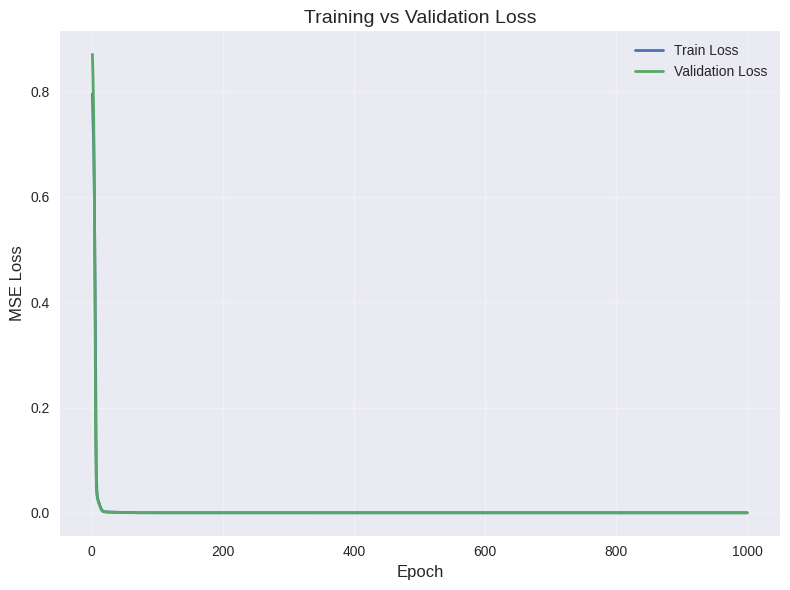

SkipMLP(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=4, bias=True)
    (1): Linear(in_features=5, out_features=2, bias=True)
    (2): Linear(in_features=2, out_features=2, bias=True)
    (3): Linear(in_features=5, out_features=1, bias=True)
    (4): Linear(in_features=5, out_features=4, bias=True)
  )
)
CopyMLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=4, bias=True)
    (9): Identity()
  )
)


[{'network_id': 'df20b8c3-e250-48c9-b24c-24dbb5fc8ff5',
  'layer_i': -1,
  'layer_j': 1,
  'layer_distance': 2,
  'layer_i_is_input': 1,
  'r2_y_given_hip1': 0.999974250793457,
  'r2_y_given_hip1_hi': 0.9999758005142212,
  'delta_r2_y_hi_given_hip1': 1.5497207641601562e-06,
  'r2_residual_y_given_hi_after_hip1': 5.364418029785156e-07,
  'cmi_proxy_hi_y_given_hip1': 0.05441457778215408,
  'varfrac_yhat_from_hip1': 0.9999901652336121,
  'varfrac_yhat_from_hip1_hi': 0.9999905228614807,
  'varfrac_increment_hi_given_hip1': 3.5762786865234375e-07,
  'nonlin_mse_rev': 0.0005967125180177391,
  'nonlin_proporition_perfect_fwd': -0.011480097658932209,
  'cka': 0.9127240777015686,
  'trustworthiness': 0.9920000000000002,
  'dec_lin_i': 0.7811038494110107,
  'dec_lin_j': 0.9999898076057434,
  'dec_lin_diff': -0.21888595819473267,
  'dec_lin_ratio': 0.7811118029993473,
  'cond_gain_R2': 2.384185791015625e-06,
  'grad_norm_i': 0.0,
  'grad_norm_j': 1.9536710169631988e-05,
  'grad_norm_diff': -1.953

In [ ]:
# UTIL
def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

def print_weights(model):
  for name, param in model.named_parameters():
      print(name, param.shape)
      print(param)

N_LAYERS = 5
SKIPS = [{}, {0}, {}, {0,2}, {1}]
A_FUNC = nn.ReLU
GENERATOR = MLPGenerator(1, N_LAYERS, lambda x: random.randint(1,5), lambda x: SKIPS[x], lambda x: A_FUNC() if x != N_LAYERS - 1 else nn.Identity())

report = train_copy_from_skip(
  GENERATOR,
  epochs=1000,
  N=1000,
  batch_size=64,
  patience=100,
  grad_clip=1.0,
  verbose=True,
  layer_comparison_width=5,
  compare_all_skips=True,
)

truth_model, model = report["truth_model"], report["model"]
X, Y = report["X"], report["Y"]
with torch.no_grad():
  Y_pred = model(X)
train_losses, val_losses = report["train_losses"], report["val_losses"]

if X.dim() == 1 and Y.dim() == 1:
  # Convert to numpy
  x = X.detach().cpu().numpy().ravel()
  y = Y.detach().cpu().numpy().ravel()
  y_hat = Y_pred.detach().cpu().numpy().ravel()

  # =======================
  # 1) X vs Y and Y_pred
  # =======================
  plt.figure(figsize=(8,6))
  plt.style.use("seaborn-v0_8")

  plt.scatter(x, y, s=18, alpha=0.8, label="Ground Truth (Y)")
  plt.scatter(x, y_hat, s=18, alpha=0.8, label="Prediction (Y_pred)", marker="x")

  plt.title("Ground Truth vs Model Prediction", fontsize=14)
  plt.xlabel("X", fontsize=12)
  plt.ylabel("Y", fontsize=12)
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

# =======================
# 2) Train & Val Loss
# =======================
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(8,6))
plt.style.use("seaborn-v0_8")

plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(truth_model)
print(model)
report["metrics_dataset"]

# Data Gen

In [ ]:
@dataclass(frozen=True)
class SkipPredictorDataGenerator:
  max_layers: int
  max_layer_width: int
  percent_skips: float = 0.3


  def create_truth_gen(self):
    def skips(i):
      if i > 1 and random.random() < self.percent_skips:
        return {random.randint(1, i-1)}
      else:
        return {}

    n_layers = random.randint(2,self.max_layers)
    return MLPGenerator(1,
                            n_layers,
                             lambda x: random.randint(1,self.max_layer_width),
                             skips,
                             lambda x: nn.ReLU() if x != n_layers - 1 else nn.Identity()
                             )

def gen_skip_predictor_data(N: int, generator: SkipPredictorDataGenerator):
  dataset = []
  models = []
  model_i = 1
  dataset_len = 0
  while dataset_len < N:
    truth_gen = generator.create_truth_gen()
    report = train_copy_from_skip(
        truth_gen,
        min_val_loss_for_metrics=1e-3,
        store_train_losses=False,
        store_val_losses=False,
        epochs=1_000_000,
        N=1000,
        batch_size=32,
        patience=300,
        grad_clip=1.0,
        print_every=200,
        verbose=True,
    )
    metrics = report["metrics_dataset"]
    best_val = report["best_val"]
    epochs = report["epochs"]
    if metrics is not None:
      dataset.extend(metrics )
      dataset_len += len(metrics)
      models.append(report["model"])
    print(f"model #{model_i} done. best_val: {best_val}. epochs: {epochs}")
    print(f"dataset size: {len(dataset)}")
    model_i += 1
  return dataset, models

def read_pickle(file_path, verbose=False):
  try:
      obj = None
      with open(file_path, 'rb') as f:
          obj = pickle.load(f)
      if verbose:
        print(f"Objects loaded from file: {file_path}")
      return obj
  except IOError as e:
      if verbose:
        print(f"Error reading from file: {e}")

def write_pickle(obj, file_path, verbose=False):
  try:
      with open(file_path, 'wb') as f:
          pickle.dump(obj, f)
      if verbose:
        print(f"obj saved to {file_path}")
  except IOError as e:
      if verbose:
        print(f"Error writing to file: {e}")

N = 400
MAX_LAYERS = 15
MAX_LAYER_WIDTH = 10
PERCENT_SKIP = 0.65
generator = SkipPredictorDataGenerator(MAX_LAYERS, MAX_LAYER_WIDTH, PERCENT_SKIP)
dataset, models = gen_skip_predictor_data(N, generator)

TO_DRIVE = "/content/drive/MyDrive/skips_data_gen"
metadata = read_pickle(f"{TO_DRIVE}/metadata.pickle")
if metadata is None:
  print("creating new metadata")
  metadata = {"iter": 0}

metadata["iter"] += 1
ITER = metadata["iter"]

TO_DATA = f"{TO_DRIVE}/data"
dta = pd.DataFrame(dataset)
file_name = f"{TO_DATA}/{ITER}-{N}_{MAX_LAYERS}_{MAX_LAYER_WIDTH}_{int(PERCENT_SKIP * 100)}.csv"
dta.to_csv(f"{file_name}", index=False)
dta.to_csv(file_name, index=False)
print(f"dataset written to: {file_name}")

TO_MODELS = f"{TO_DRIVE}/models"
print(f"# of models: {len(models)}")
for model in models:
  id = str(model.model_id)
  model_file_name = f"{TO_MODELS}/{ITER}-weights_{id}.pt"
  torch.save(model, model_file_name)
  print(f"model weights written to: {model_file_name}")
  struct_file_name = f"{TO_MODELS}/{ITER}-struct_{id}.pickle"
  write_pickle(model.init_struct, struct_file_name)


write_pickle(metadata, f"{TO_DRIVE}/metadata.pickle")
print(f"metadata written to: {TO_DRIVE}/metadata.pickle")

Epoch    0 | Train 0.202787 | Val 0.119224
Epoch  200 | Train 0.000001 | Val 0.000001

Early stopping at epoch 391

Final Train Loss: 0.000001
Final Val Loss:   0.000001
Computing metrics...
model #1 done. best_val: 6.292933676377288e-07. epochs: 391
dataset size: 10
Epoch    0 | Train 0.129492 | Val 0.089820
Epoch  200 | Train 0.000004 | Val 0.000003
Epoch  400 | Train 0.000004 | Val 0.000003
Epoch  600 | Train 0.000004 | Val 0.000003
Epoch  800 | Train 0.000004 | Val 0.000003

Early stopping at epoch 845

Final Train Loss: 0.000004
Final Val Loss:   0.000003
Computing metrics...
model #2 done. best_val: 2.980540330099757e-06. epochs: 845
dataset size: 22
Epoch    0 | Train 1.379212 | Val 0.526220
Epoch  200 | Train 0.000009 | Val 0.000010
Epoch  400 | Train 0.000003 | Val 0.000004
Epoch  600 | Train 0.000002 | Val 0.000002
Epoch  800 | Train 0.000001 | Val 0.000001
Epoch 1000 | Train 0.000000 | Val 0.000001
Epoch 1200 | Train 0.000000 | Val 0.000001
Epoch 1400 | Train 0.000000 | Val 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
